> Mostly follows priyam's code

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


import torch.optim as optim
from tqdm import tqdm
from matplotlib.animation import FuncAnimation




In [2]:
transform = transforms.Compose(
    [
        transforms.Resize((32,32)),
        transforms.ToTensor()
    ]
)

train_set = MNIST("../data/mnist/", train=True, transform=transform, download=True)
test_set = MNIST("../data/mnist/", train=False, transform=transform, download=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.23MB/s]


### Conv auto-encoder

In [3]:
for img, label in train_set:
    print(img, label)
    break

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]) 5


In [4]:
batch_size = 4
train = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val = DataLoader(test_set, batch_size=batch_size, shuffle=False)

for x, y in train:
    print(x.shape, y.shape)
    break

torch.Size([4, 1, 32, 32]) torch.Size([4])


In [5]:
class LinearAutoEncoder(nn.Module):
    def __init__(self, bottleneck = 2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(32*32, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, bottleneck)
        )

        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 32*32),
            nn.Sigmoid()
        )

    def forward_enc(self, x):
        return self.encoder(x)

    def forward_dec(self, x):
        x = self.decoder(x)
        return x.reshape(-1,1,32,32)

    def forward(self, x):
        x = x.flatten(1)
        enc = self.forward_enc(x)
        dec = self.forward_dec(enc)
        return enc, dec

model = LinearAutoEncoder( )
for x, y in train:
    enc, dec = model(x)
    print(x.shape, enc.shape, dec.shape)
    break
model

torch.Size([4, 1, 32, 32]) torch.Size([4, 2]) torch.Size([4, 1, 32, 32])


LinearAutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1024, bias=True)
    (7): Sigmoid()
  )
)

In [6]:
class ConvAutoEncoder(nn.Module):
    def __init__(self, in_channels = 1, bottleneck = 4):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d( in_channels=in_channels, out_channels= 8, kernel_size=3, stride=2, padding=1, bias=False ),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.Conv2d( in_channels=8, out_channels= 16, kernel_size=3, padding=1, stride=2, bias=False ),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d( in_channels=16, out_channels= bottleneck, kernel_size=3, padding=1, stride=2),

        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d( in_channels = bottleneck, out_channels=16, kernel_size=3, padding=1, stride=2, output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.ConvTranspose2d( in_channels = 16, out_channels=8, kernel_size=3, padding=1, stride=2, output_padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.ConvTranspose2d( in_channels = 8, out_channels=in_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward_enc(self, x):
        return self.encoder(x)

    def forward_dec(self, x):
        return self.decoder(x)

    def forward(self, x):
        enc = self.forward_enc(x)
        dec = self.forward_dec(enc)
        return enc, dec


model = ConvAutoEncoder( )
for x, y in train:
    enc, dec = model(x)
    print(x.shape, enc.shape, dec.shape)
    break
model

torch.Size([4, 1, 32, 32]) torch.Size([4, 4, 4, 4]) torch.Size([4, 1, 32, 32])


ConvAutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(16, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(4, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(8, 1, kernel_size=(3, 3), str

In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)
model = ConvAutoEncoder().to(DEVICE)
ln_model = ConvAutoEncoder().to(DEVICE)
optm = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

cuda


In [8]:
def train_model(max_steps, eval_iter, model, train_data_loader, val_data_loader,
                optm, loss_fn, model_type = "AE"):
    logs = {
        "step" : [],
        "training_loss": [],
        "val_loss": [],
    }
    continue_train = True
    train_loss, eval_loss, step_counter = [], [], 0
    encoded_evals = []
    pbar = tqdm(range(max_steps))

    while continue_train:
        for x, labels in train_data_loader:
            step_counter += 1

            x = x.to(DEVICE) # Move data to the device
            if model_type == "AE":
              z, dec = model(x)
              loss = loss_fn(dec, x)
            elif model_type == "VAE":
              z, mu, log_var, dec = model(x)
              loss = loss_fn(x, dec, mu, log_var)
            optm.zero_grad()
            loss.backward()
            optm.step()
            train_loss.append(loss.item())

            if step_counter % eval_iter == 0:
                logs["training_loss"].append(np.mean(train_loss))
                logs["step"].append(step_counter)
                encoded_data = []

                with torch.no_grad():
                    for x, labels in val_data_loader:
                        x = x.to(DEVICE) # Move data to the device
                        if model_type == "AE":
                          z, dec = model(x)
                          loss = loss_fn(dec, x)
                        elif model_type == "VAE":
                          z, mu, log_var, dec = model(x)
                          loss = loss_fn(x, dec, mu, log_var)
                        eval_loss.append(loss.item())

                        z, labels = z.cpu().flatten(1), labels.reshape(-1,1)
                        encoded_data.append(torch.cat((z, labels), axis=-1))

                encoded_evals.append(torch.concatenate(encoded_data))
                logs["val_loss"].append(np.mean(eval_loss))

                train_loss, eval_loss = [], []

                print(
                    f"Step {step_counter}/ {max_steps} | "
                    f"Train Loss: {logs['training_loss'][-1]:.4f} | Val Loss: {logs['val_loss'][-1]:.4f} "
                )

            pbar.update(1)
            if step_counter >= max_steps:
                print("Training completed")
                continue_train = False
                break

    return model, logs, encoded_evals

In [ ]:
trained_model, logs, encoded_evals = train_model(model=model, max_steps=25000, eval_iter=250,
                    train_data_loader=train, val_data_loader=val, optm=optm, loss_fn=criterion)

In [ ]:
encoded_evals[0].shape

torch.Size([10000, 33])

In [ ]:
generated_index = 0
image, label = test_set[generated_index]

_, conv_reconstructed = model(image.unsqueeze(0).to(DEVICE))

conv_reconstructed = conv_reconstructed.to("cpu").detach().numpy()

fig, ax = plt.subplots(1,2)

ax[0].imshow(image.squeeze(), cmap="gray")
ax[0].set_title("Original Image")
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])
ax[0].axis("off")

ax[1].imshow(conv_reconstructed.squeeze(), cmap="gray")
ax[1].set_title("Conv AutoEncoder")
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
ax[1].axis("off")


plt.show()


## VAE

### **KL Divergence**

For Gaussian latent distributions $( q(z|x) = N(\mu, \sigma^2) )$:

$
\text{KL}(q(z|x) ,||, p(z)) = -\frac{1}{2} \sum (1 + \log\sigma^2 - \mu^2 - \sigma^2)
$

PyTorch code:

```python
kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
```

---

### **Combined Loss**

```python
loss = recon_loss + beta * kl_loss
```



In [51]:
len(train)

15000

Why mu and logvar are Conv2d? why not a single latent vector?

- In a **ConvVAE**, the encoder is convolutional and outputs a **spatial feature map**

Now, instead of flattening to one vector, we interpret this as a **grid of latent variables**:

* Each spatial position (i,j) has its own latent Gaussian ( z_{i,j} \sim \mathcal{N}(\mu_{i,j}, \sigma_{i,j}^2) ).
* The decoder then reconstructs the image by conditioning on the *whole latent map* ( z ).

- So `μ` and `log_var` need to be **convolutional outputs** with the same spatial shape — `[B, C, H_latent, W_latent]`.

- each spatial location in the bottleneck has its own mean and variance.


- Use single latent vector when we explicitly want a *global latent code* representing the whole image.

In [10]:
def VAELoss(x, recon_x, mu, log_var, kl_weight = 1, recon_weight = 1):
    """
    Computes the VAE loss.
    - Here we are calculating recon loss and kl loss per image.

    :param x: input data. Shape: [B, C, H, W]
    :param recon_x: reconstructed data
    :param mu: mean of the latent distribution
    :param log_var: log variance of the latent distribution
    :param beta: weight for the KL divergence
    """
    ## Note: kl loss and reconstruction loss needs to be in similar scale for comparision.
    ## i.e if we are avgeraging per image for kl loss, then use mse or else use summation loss for both.
    kl = ( 1 + log_var - mu.pow(2) - log_var.exp() ).flatten(1)
    kl_per_image = -0.5 * torch.sum(kl, dim=-1 )
    kl_loss = torch.mean(kl_per_image)

    # reconstruction loss
    pixel_mse = ( recon_x.flatten(1) - x.flatten(1) ) ** 2
    recon_loss = pixel_mse.sum(dim = -1).mean()

    loss = recon_weight * recon_loss + kl_weight * kl_loss
    return loss

class ConvVAE(nn.Module):
    def __init__(self, in_channels = 1, bottleneck = 4):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d( in_channels=in_channels, out_channels= 8, kernel_size=3, stride=2, padding=1, bias=False ),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.Conv2d( in_channels=8, out_channels= 16, kernel_size=3, padding=1, stride=2, bias=False ),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d( in_channels=16, out_channels= bottleneck, kernel_size=3, padding=1, stride=2),

        )

        ## variables for gaussian latent dim
        self.mu = nn.Conv2d(in_channels=bottleneck, out_channels = bottleneck, kernel_size=3, stride=1, padding='same')
        self.log_var = nn.Conv2d(in_channels=bottleneck, out_channels = bottleneck, kernel_size=3, stride=1, padding='same')
        ##

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d( in_channels = bottleneck, out_channels=16, kernel_size=3, padding=1, stride=2, output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.ConvTranspose2d( in_channels = 16, out_channels=8, kernel_size=3, padding=1, stride=2, output_padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.ConvTranspose2d( in_channels = 8, out_channels=in_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )


    def forward_enc(self, x):
        x = self.encoder(x)

        mu = self.mu(x)
        log_var = self.log_var(x)

        sigma = torch.exp(0.5 * log_var)
        noise = torch.randn_like(sigma, device=sigma.device)
        z = mu + sigma * noise

        return z, mu, log_var

    def forward_dec(self, x):
        return self.decoder(x)

    def forward(self, x):
        z, mu, log_var = self.forward_enc(x)

        dec = self.forward_dec(z)
        return z, mu, log_var, dec


convvae_model = ConvVAE().to(DEVICE)
for x, y in train:
    x = x.to(DEVICE)
    y = y.to(DEVICE)
    z, mu, log_var, dec = convvae_model(x)
    print(x.shape, z.shape, dec.shape)
    loss = VAELoss(x, dec, mu, log_var, 1, 1)
    print(loss)
    break
convvae_model

torch.Size([4, 1, 32, 32]) torch.Size([4, 4, 4, 4]) torch.Size([4, 1, 32, 32])
tensor(272.4902, device='cuda:0', grad_fn=<AddBackward0>)


ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(16, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  )
  (mu): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (log_var): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (decoder): Sequential(
    (0): ConvTranspose2d(4, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): BatchNorm2d(

In [12]:
optm = optim.Adam(convvae_model.parameters(), lr=1e-3)
vae_trained_model, vae_logs, vae_encoded_evals = train_model(model=convvae_model, max_steps=25000, eval_iter=250,
                    train_data_loader=train, val_data_loader=val, optm=optm, loss_fn=VAELoss, model_type="VAE")


  1%|          | 276/25000 [00:06<25:14, 16.33it/s]

Step 250/ 25000 | Train Loss: 142.7612 | Val Loss: 89.4734 



  2%|▏         | 520/25000 [00:14<30:50, 13.23it/s]

Step 500/ 25000 | Train Loss: 75.2921 | Val Loss: 68.0916 



  3%|▎         | 777/25000 [00:21<25:05, 16.09it/s]

...

Step 24500/ 25000 | Train Loss: 47.8488 | Val Loss: 47.9555 



 99%|█████████▉| 24785/25000 [11:13<00:14, 14.36it/s]

Step 24750/ 25000 | Train Loss: 47.2690 | Val Loss: 47.9559 



100%|██████████| 25000/25000 [11:19<00:00, 36.78it/s] 

Step 25000/ 25000 | Train Loss: 47.8707 | Val Loss: 47.9456 
Training completed


In [54]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [66]:
folder_path = r"/content/drive/MyDrive/Notebook\ -\ practise/data_files/"
os.makedirs(folder_path, exist_ok=True)
folder_path

'/content/drive/MyDrive/Notebook\\ -\\ practise/data_files/'

In [63]:
torch.save({
    "model_state": vae_trained_model.state_dict(),
    "logs": vae_logs,
    "encoded": vae_encoded_evals
}, folder_path + "vae_full_checkpoint.pth")


In [ ]:
vae_trained_model, vae_logs, vae_encoded_evals

In [22]:
for x, y in val:
    print(x.shape, y)
    break

torch.Size([4, 1, 32, 32]) tensor([7, 2, 1, 0])


In [24]:
len(val), vae_encoded_evals[1].shape


(2500, torch.Size([10000, 65]))

In [38]:
## 10k -> samples ; 65 -> 64 (C x H x W) + 1 (labels)
convvae_latent.shape

torch.Size([10000, 65])

In [42]:
convvae_latent = vae_encoded_evals[-1][:2000]

convvae_latent_features, convvae_latent_labels = convvae_latent[ : , :-1], convvae_latent[ : , -1].reshape(1, -1)
compressed_latents = TSNE(n_components=2, learning_rate='auto',
                            init='random',
                            verbose=1,
                            n_jobs=-1).fit_transform(convvae_latent_features)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.001s...
[t-SNE] Computed neighbors for 2000 samples in 0.076s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 2.169484
[t-SNE] KL divergence after 250 iterations with early exaggeration: 76.740059
[t-SNE] KL divergence after 1000 iterations: 2.733849


In [46]:

compressed_latents.shape, convvae_latent_labels.reshape(1,-1).shape

((2000, 2), torch.Size([1, 2000]))

In [50]:
import seaborn as sns

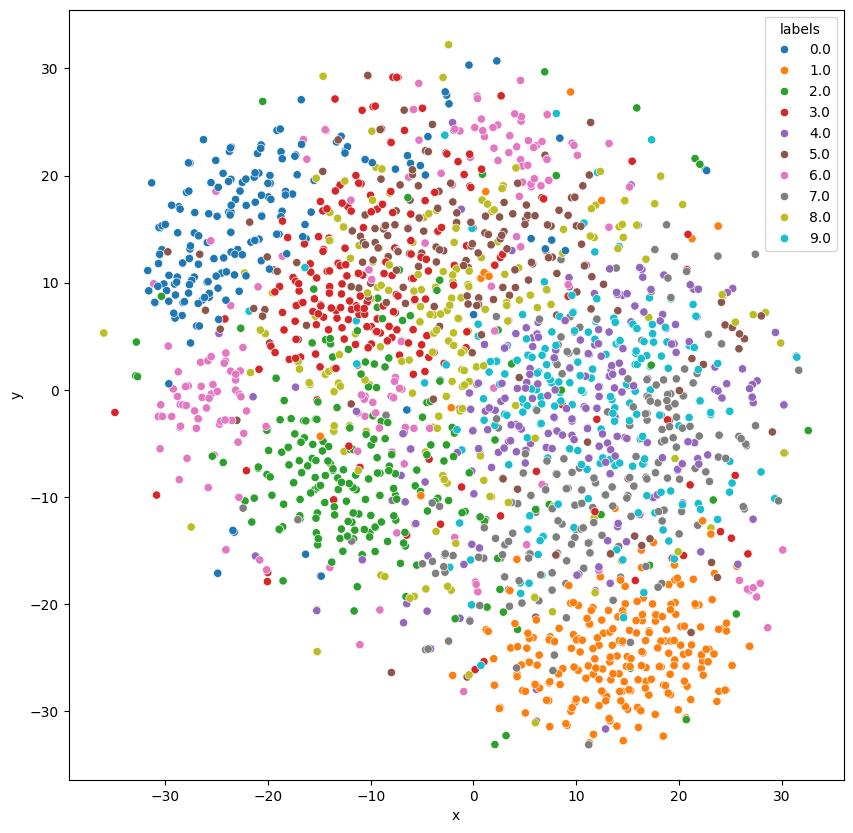

In [53]:
conv_reduced = pd.DataFrame( np.hstack((compressed_latents, convvae_latent_labels.reshape(-1,1))), columns=['x', 'y', 'labels'] )
plt.figure(figsize=(10,10))
sns.scatterplot(x='x', y='y', hue='labels', data=conv_reduced, palette='tab10')
plt.show()

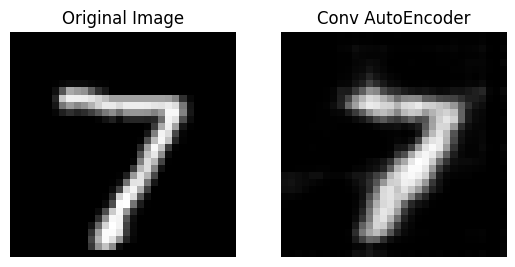

In [77]:
generated_index = 0
image, label = test_set[generated_index]

_, _, _, conv_reconstructed = convvae_model(image.unsqueeze(0).to(DEVICE))

conv_reconstructed = conv_reconstructed.to("cpu").detach().numpy()

fig, ax = plt.subplots(1,2)

ax[0].imshow(image.squeeze(), cmap="gray")
ax[0].set_title("Original Image")
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])
ax[0].axis("off")

ax[1].imshow(conv_reconstructed.squeeze(), cmap="gray")
ax[1].set_title("Conv AutoEncoder")
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
ax[1].axis("off")


plt.show()


# Experiments 

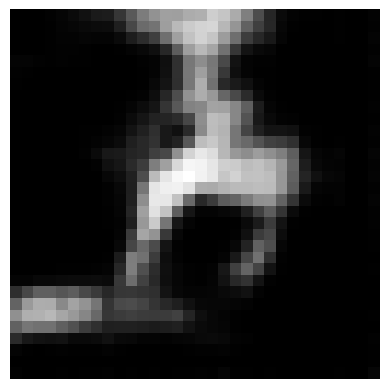

In [95]:
rand_samp = torch.randn((1, 4, 4,4)).to(DEVICE)
generated_img = convvae_model.forward_dec(rand_samp)


plt.imshow(generated_img[0,0].cpu().detach(), cmap='gray')
plt.axis('off')
plt.show()

Let’s go much deeper into **why generating images from a random latent vector often fails in VAEs**, step by step, with intuition and math behind it.

---

## 1 Latent space distribution

### How VAEs encode data

In a VAE, for an input (x):

$z \sim \mathcal{N}(\mu(x), \sigma(x)^2)$

* The encoder outputs (\mu(x)) and (\log \sigma^2(x)).
* The latent vector (z) is sampled from this Gaussian.
* The decoder then reconstructs (x) from (z): (x' = f_\theta(z)).

**Important:**

* During training, the decoder **only sees latent vectors (z) that come from training images**.
* These (z) values are **clustered around the means (\mu(x))** with some variance (\sigma^2(x)).
* Mathematically, the prior is standard normal (p(z) = \mathcal{N}(0, I)), but the encoder usually **doesn’t perfectly cover all of latent space**, only the regions that correspond to real images.

---

### Why sampling `torch.randn((1,4,4,4))` often fails

* `torch.randn` samples from **standard normal** across all latent dimensions independently.
* Many sampled points will be **far from any (\mu(x)) seen during training**, in regions the decoder never trained on.

Imagine latent space as a 2D example:

```
Encoded data points (latent z) ≈ small clusters around Gaussian blobs
Random sample from N(0,1) → could be far outside clusters
Decoder never learned to map these “empty” regions → output = noise
```

So, most random points in high-dimensional space are **off the manifold** of valid latent codes.

---

## 2. Small latent size

Your model has:

* Bottleneck = 4 channels, output shape `[4,4,4]` → 64 latent dimensions
* Input images = `[1,32,32]` → 1024 pixels

**Implications:**

* Latent space is **tiny relative to input dimensionality** → decoder must map from **very compressed space to high-dimensional images**.
* High-dimensional mappings are extremely sensitive: **small changes in latent vector can produce large, meaningless variations in output**.
* With only 64 latent variables, most random points are unlikely to correspond to any realistic image.

> This is a common reason small VAEs produce “blurry or noisy” random samples.

---

## 3. Insufficient training

Even if you use latent vectors from the **training distribution**, the decoder may still produce bad outputs if it hasn’t fully learned the mapping:

* Early in training, reconstructions are noisy → decoder weights are not well-optimized.
* Decoder has not seen a wide variety of latent codes → fails to generalize.

**Tip:** Only after **loss stabilizes and reconstructions look good** does random sampling produce meaningful outputs.

---

## 4. Summary (Intuition)

1. **Latent space is only partially populated** — random vectors often lie in “empty regions” → decoder produces nonsense.
2. **Small latent space** makes the mapping very sensitive → random points far from clusters produce noise.
3. **Decoder quality** depends on training — insufficient training → bad outputs even for valid latent codes.

---

### ractical consequence

To generate meaningful random images:

1. Sample **around the latent codes of the training data** (add small Gaussian noise).
2. Use a **larger latent dimension** to give decoder more capacity.
3. Train until **reconstructions are good**.
4. Optionally, use **latent space interpolation** instead of completely random sampling.



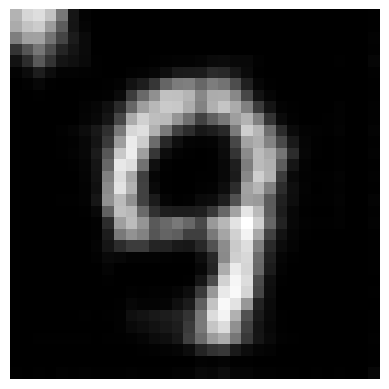

In [101]:
## here we are randomly taking latent feature of eval's

idx = torch.randint(0, convvae_latent_features.shape[0], (1,))
sample_z = convvae_latent_features[idx].reshape(1, 4, 4, 4).to(DEVICE)
generated_img = convvae_model.forward_dec(sample_z)

plt.imshow(generated_img[0,0].cpu().detach(), cmap='gray')
plt.axis('off')
plt.show()


In [106]:
vae_encoded_evals[0].shape

torch.Size([10000, 65])

In [123]:
vae_encoded_evals[-1][ :, :-1].shape

torch.Size([10000, 64])

In [132]:
#latent_vectors = torch.cat([z[:, :-1] for z in vae_encoded_evals], dim=0)  # shape [N, latent_dim]
mu = vae_encoded_evals[-1][:, :-1].mean(dim=0)
sigma = vae_encoded_evals[-1][:, :-1].std(dim=0)

latent_vectors.shape, mu.shape, sigma.shape


(torch.Size([1000000, 64]), torch.Size([64]), torch.Size([64]))

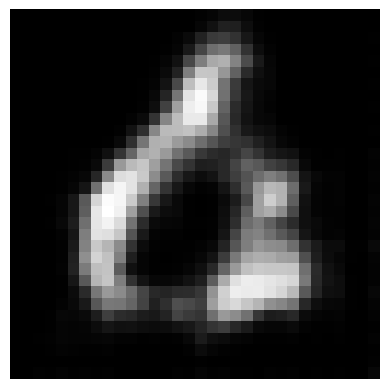

In [163]:
rand_samp = torch.randn((1, 4, 4, 4)).to(DEVICE) * sigma.view(1,4,4,4).to(DEVICE) + mu.view(1,4,4,4).to(DEVICE)
generated_img = convvae_model.forward_dec(rand_samp)
plt.imshow(generated_img[0,0].cpu().detach(), cmap='gray')
plt.axis('off')
plt.show()

## The core reason: latent space is **not uniformly “good” everywhere**

Even if training is complete:

1. **VAE only sees latent vectors produced by the encoder during training.**

   * `mu`/`sigma` computed from the encoded validation set gives the **mean and std of the *flattened latent vectors***.
   * But the **decoder has only ever seen structured combinations of latent features** corresponding to real images.

2. **Randomly sampling each latent dimension independently (even scaled by sigma)** creates points that **may not correspond to any valid encoding**.

   * High-dimensional latent space is mostly empty.
   * Points drawn independently from a Gaussian may fall into these “empty” regions → decoder outputs noise.

> In other words, **VAE decoder doesn’t “know” what to do with most of the latent space**, only the regions visited by the encoder during training.

---

## Small latent dimension issue

ConvVAE has:

* Bottleneck = 4 → `[4,4,4]` → 64 latent dims
* Input = `[1,32,32]` → 1024 pixels

Problems:

* 64 latent dimensions is tiny → the decoder has **little flexibility**.
* Even valid latent vectors can produce blurry images because **information is heavily compressed**.
* Sampling outside the exact manifold of encoded points usually produces garbage.

---

## Why μ/σ scaling doesn’t solve it

When you do:

```python
rand_samp = torch.randn((1,4,4,4)) * sigma.view(1,4,4,4) + mu.view(1,4,4,4)
```

* Each latent dimension is independent.
* But the **encoder produces correlated latent dimensions**; e.g., z1 may only take certain values if z2 is in a particular range.
* Sampling independently ignores this correlation → you get points **off the learned manifold** → bad images.

---

## Correct ways to generate meaningful images

### Option A: Sample from **actual latent vectors**

```python
# Pick a latent vector from the validation set
idx = torch.randint(0, vae_encoded_evals[-1].shape[0], (1,))
sample_z = vae_encoded_evals[-1][idx, :-1].reshape(1,4,4,4).to(DEVICE)
generated_img = convvae_model.forward_dec(sample_z)
```

Always produces realistic images, because decoder has seen these latent vectors.

---

### Option B: Add small noise around a real latent vector

```python
sample_z = vae_encoded_evals[-1][idx, :-1].reshape(1,4,4,4).to(DEVICE)
noise = 0.1 * torch.randn_like(sample_z)  # small perturbation
rand_samp = sample_z + noise
generated_img = convvae_model.forward_dec(rand_samp)
```

* Explores nearby latent space → variations of real images without going off-manifold.

---

### Option C: Use a **larger latent dimension and well-trained model**

* Bottleneck ≥ 16 → decoder can generalize better
* KL weight annealing during training → smoother latent space
* This allows sampling from a standard normal and generating decent images.

---

### Summary

Even with “complete training”:

* Random N(0,1) or μ/σ-based latent samples **don’t guarantee realistic images**.
* Decoder only knows latent vectors that correspond to real images → off-manifold points produce garbage.
* Safe approach: **sample from latent vectors the encoder produced**, optionally add small noise.
